Marker(eid="PA1RFGUN")
Quadrupole(l=0.07360, k1=-4.662753e+01, eid="QDA1G1")
Quadrupole(l=0.07360, k1=4.709763e+01, eid="QFA1G2")
Bend(eid="BXA1G")
Bend(tilt=1.570796e+00, eid="BYA1G")
Quadrupole(l=0.07360, k1=-8.030131e+00, eid="QDA101")
Quadrupole(l=0.07360, k1=2.957378e+00, eid="QFA102")
Marker(eid="PACA11")
Cavity(l=0.61850, v=6.662282e-03, freq=2.856000e+09, phi=4.000000e+01, eid="ACA111")
Bend(eid="SXA11")
Bend(tilt=1.570796e+00, eid="SYA11")
Cavity(l=1.27095, v=1.369683e-02, freq=2.856000e+09, phi=4.000000e+01, eid="ACA112")
Marker(eid="PACA11")
Quadrupole(l=0.07360, k1=-1.142003e-01, eid="QDA111")
Quadrupole(l=0.11460, k1=5.928660e+00, eid="QFA112")
Quadrupole(l=0.07360, k1=-7.876449e-03, eid="QDA113")
Bend(l=0.14725, angle=1.605878e-01, e2=1.605878e-01, eid="BMA1C1")
Bend(l=0.14725, angle=-1.605878e-01, e1=-1.605878e-01, eid="BMA1C2")
Bend(l=0.14725, angle=-1.605878e-01, e2=-1.605878e-01, eid="BMA1C3")
Bend(l=0.14725, angle=1.605878e-01, e1=1.605878e-01, eid="BMA1C4")
Bend(l=0

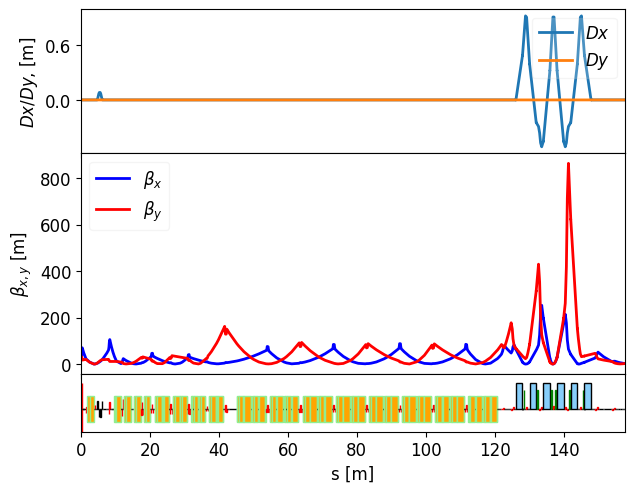

In [217]:
from ocelot import *
from ocelot.cpbd.elements import *
from ocelot.gui.accelerator import *
from ocelot.cpbd.track import track_debug
import matplotlib.pyplot as plt


from linaccopy import *

# # Define a very simple lattice: one big drift
# # Define elements
# drift_length = 50.0  # meters
# drift = Drift(l=drift_length, eid="D1")

# cavity_voltage = 5e6  # 5 MV (can adjust)
# cavity = Cavity(l=10, eid="CAV1")  # simple 0.5 m cavity
# cavity.voltage = cavity_voltage  # Voltage in Volts
# cavity.freq = 1.3e9  # 1.3 GHz typical frequency
# cavity.phase = 0.0   # 0° synchronous phase (can play with later)

# # Create the toy lattice: Cavity + Drift
# toy_lat = MagneticLattice([cavity, drift])

lat = MagneticLattice(guntoC)

# #lat = toy_lat

# === Define Cavity ===
cavity_voltage = 5e6  # 5 MV (can adjust)
cavity = Cavity(l=10, eid="CAV1")
cavity.voltage = cavity_voltage
cavity.freq = 1.3e9  # 1.3 GHz
cavity.phase = -20.0  # <<< Off-crest phase to introduce chirp!

# === Define Chicane (4 Dipoles) ===
# Parameters
bend_length = 1.0    # meters
bend_angle = 0.05    # radians (about 2.8 degrees)

# Bends
b1 = SBend(l=bend_length, angle=+bend_angle, eid="B1")
b2 = SBend(l=bend_length, angle=-bend_angle, eid="B2")
b3 = SBend(l=bend_length, angle=-bend_angle, eid="B3")
b4 = SBend(l=bend_length, angle=+bend_angle, eid="B4")

# Drifts between bends
dr1 = Drift(l=1.0, eid="D1")   # between B1 and B2
dr2 = Drift(l=2.0, eid="D2")   # middle drift between B2 and B3
dr3 = Drift(l=1.0, eid="D3")   # between B3 and B4

# === Define Drift after Chicane ===
drift_length = 50.0  # meters
drift_after = Drift(l=drift_length, eid="D4")

# === Build Full Toy Lattice ===
toy_lat = MagneticLattice([
    cavity,
    b1, dr1, b2, dr2, b3, dr3, b4,   # chicane section
    drift_after                      # long drift after compression
])

# Final lattice you will track on:
#lat = toy_lat



##### PA1RFGUN #####
AX =-21.12   
BX =24.36 
AY =-21.16     
BY =24.42      
EMITX =1.2023504614117648e-06
EMITY =1.2023504614117648e-06 
DP =.01
energy = 0.0091
##### PA1RFGUN #####

##### PSECTB #####
# AX =.8330530584703799  
# BX =8.804855185360497    
# AY =.8104567519439174
# BY =8.82335409438248       
# EMITX =10.2023504614117648e-06 
# EMITY =10.2023504614117648e-06 
##### PSECTB #####



 # GeV  #why?
tw0 = Twiss()
tw0.alpha_x = AX
tw0.beta_x = BX

tw0.alpha_y = AY
tw0.beta_y = BY
tw0.E = energy
tw0.emit_xn = EMITX 
tw0.emit_yn = EMITY
tw0.emit_x = EMITX   / energy * 0.511e-3
tw0.emit_y = EMITY / energy * 0.511e-3

tws = twiss(lat,tw0)

plot_opt_func(lat, tws,legend=False, grid=False, top_plot=['Dx','Dy'])


for elem in lat.sequence:
    if not isinstance(elem, Drift):
        print(elem)

In [218]:
def gauss_from_twiss_vec(emit, beta, alpha, size=1):
    phi = 2 * np.pi * np.random.rand(size)
    u = np.random.rand(size)
    a = np.sqrt(-2 * np.log(1 - u) * emit)
    x = a * np.sqrt(beta) * np.cos(phi)
    xp = -a / np.sqrt(beta) * (np.sin(phi) + alpha * np.cos(phi))
    return x, xp

nparticles = 100000
p_array = ParticleArray(n=nparticles)

# sigma_tau = 6.7e-3  # (bunch length in)
# sigma_p = 5.e-4     # relative momentum spread (Δp/p)  

sigma_tau = 4e-3  # (bunch length in )
sigma_p = 0.001     # relative momentum spread (Δp/p)  


p_array.E = energy  # GeV

# Longitudinal
p_array.rparticles[4] = np.random.randn(nparticles) * sigma_tau
p_array.rparticles[5] = np.random.randn(nparticles) * sigma_p

# Transverse: vectorized sampling from Twiss parameters
x, xp = gauss_from_twiss_vec(tw0.emit_x, tw0.beta_x, tw0.alpha_x, size=nparticles)
y, yp = gauss_from_twiss_vec(tw0.emit_y, tw0.beta_y, tw0.alpha_y, size=nparticles)

p_array.rparticles[0] = x
p_array.rparticles[1] = xp
p_array.rparticles[2] = y
p_array.rparticles[3] = yp

# Charge distribution
charge = 4.0e-9  # nC
p_array.q_array = np.ones(nparticles) * (charge / nparticles)




In [ ]:
from ocelot.cpbd.physics_proc import PhysProc

class CustomLongitudinalWake(PhysProc):
    def __init__(self, beam_radius=0.01, bunch_length=4e-3):
        super().__init__()
        self.Z0 = 377  # Ohm
        self.a = beam_radius
        self.L = bunch_length
        self.N = None

    def apply(self, p_array, step_size):
        z = p_array.rparticles[4]
        q = p_array.q_array
        
        if self.N is None:
            self.N = len(z)
        
        z_mean = np.mean(z)
        s = z - z_mean  # centered z
        
        # Resistive Wall Wake approximation: ~ 1/sqrt(-z)
        wake = np.zeros_like(s)
        mask = s < 0  # only trailing particles feel the wake
        wake[mask] = 1.0 / np.sqrt(-s[mask] + 1e-12)  # add epsilon to avoid division by zero
        
        # Normalize and scale
        W0 = 1e5  # Scaling factor [V/C/m^1/2], can adjust
        voltage = - (self.N * np.abs(q[0]) * self.Z0 * W0 / (self.a**2)) * wake


        
        # Apply kick
        delta_E = voltage * step_size
        E = p_array.E  # GeV
        delta_dp_p = delta_E / (E * 1e9)
        
        p_array.rparticles[5] += delta_dp_p




s = 0.500 m, σ_τ = 3.980e-03 s
z = 0.5 / 157.8181392000003. Applied: HookProcesss = 1.000 m, σ_τ = 3.980e-03 s
z = 1.0 / 157.8181392000003. Applied: HookProcesss = 1.500 m, σ_τ = 3.980e-03 s
z = 1.5 / 157.8181392000003. Applied: HookProcesss = 2.000 m, σ_τ = 3.974e-03 s
z = 2.0 / 157.8181392000003. Applied: HookProcesss = 2.500 m, σ_τ = 3.930e-03 s
z = 2.5 / 157.8181392000003. Applied: HookProcesss = 3.000 m, σ_τ = 3.885e-03 s
z = 3.0 / 157.8181392000003. Applied: HookProcesss = 3.500 m, σ_τ = 3.849e-03 s
z = 3.5 / 157.8181392000003. Applied: HookProcesss = 4.000 m, σ_τ = 3.821e-03 s
z = 4.0 / 157.8181392000003. Applied: HookProcesss = 4.500 m, σ_τ = 3.795e-03 s
z = 4.5 / 157.8181392000003. Applied: HookProcesss = 5.000 m, σ_τ = 3.845e-03 s
z = 5.0 / 157.8181392000003. Applied: HookProcesss = 5.500 m, σ_τ = 2.344e-03 s
z = 5.5 / 157.8181392000003. Applied: HookProcesss = 6.000 m, σ_τ = 1.029e-03 s
z = 6.0 / 157.8181392000003. Applied: HookProcesss = 6.500 m, σ_τ = 1.056e-03 s
z = 6.5 /

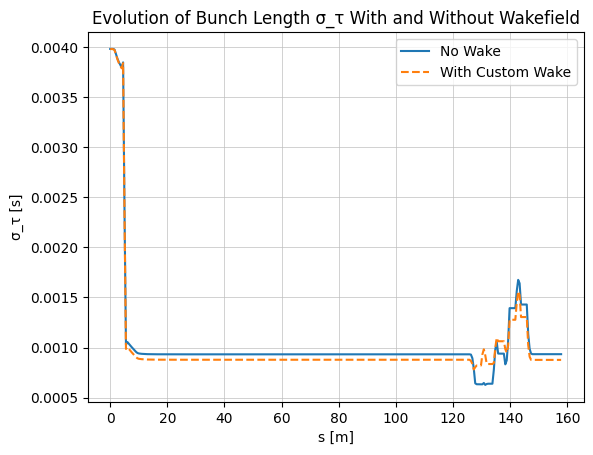

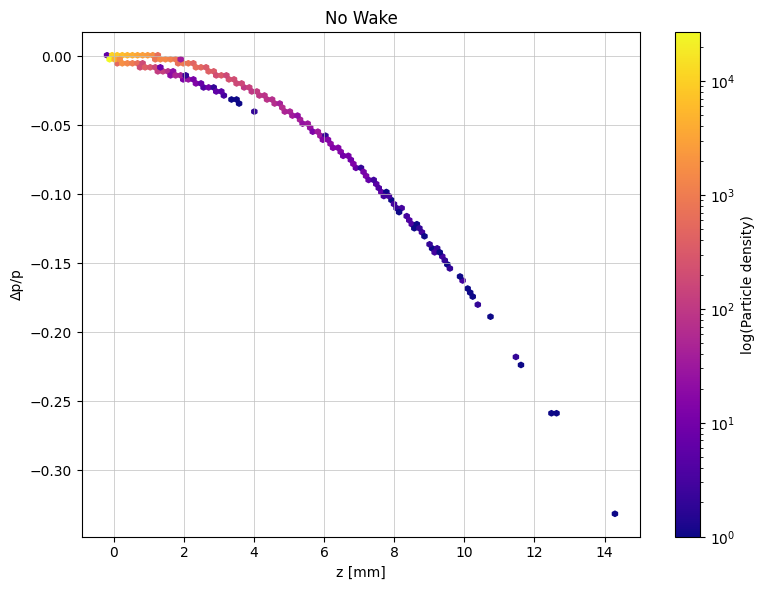

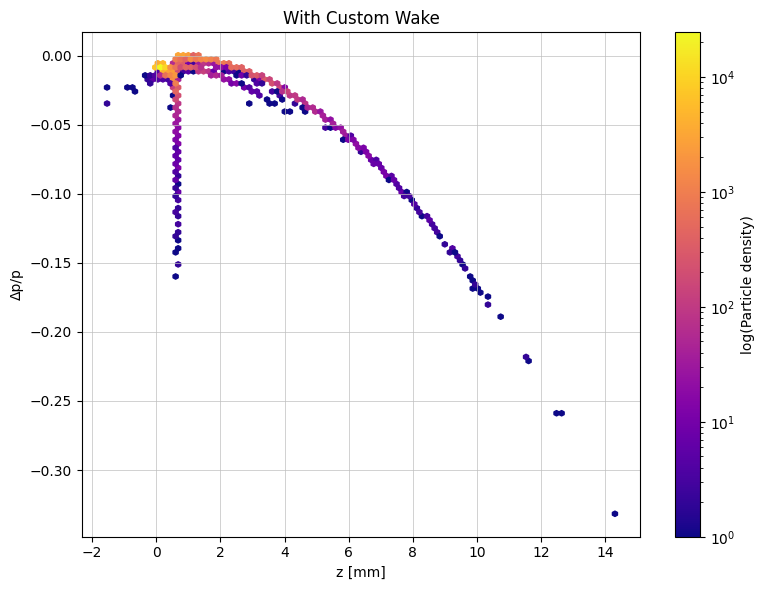

In [220]:
import time
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from ocelot.cpbd.physics_proc import PhysProc

# Define the HookProcess to monitor sigma_tau
class HookProcess(PhysProc):
    def __init__(self, sigma_tau_list):
        super().__init__()
        self.sigma_tau_list = sigma_tau_list

    def apply(self, p_array, step_size):
        sigma_tau = np.std(p_array.rparticles[4])
        self.sigma_tau_list.append(sigma_tau)
        print(f"s = {self.z0:.3f} m, σ_τ = {sigma_tau:.3e} s")

# === TRACK WITHOUT WAKEFIELD ===
p_array_no_wake = deepcopy(p_array)

navi_no_wake = Navigator(lat)
navi_no_wake.unit_step = 0.5

sigma_tau_list_no_wake = []
hook_no_wake = HookProcess(sigma_tau_list_no_wake)
navi_no_wake.add_physics_proc(hook_no_wake, lat.sequence[0], lat.sequence[-1])

tws_no_wake, p_array_no_wake = track(lat, p_array_no_wake, navi_no_wake)

# === TRACK WITH CUSTOM WAKEFIELD ===
p_array_wake = deepcopy(p_array)

navi_wake = Navigator(lat)
navi_wake.unit_step = 0.5

sigma_tau_list_wake = []
hook_wake = HookProcess(sigma_tau_list_wake)
navi_wake.add_physics_proc(hook_wake, lat.sequence[0], lat.sequence[-1])

# Add custom wake
wake_proc = CustomLongitudinalWake(beam_radius=0.01, bunch_length=sigma_tau)
navi_wake.add_physics_proc(wake_proc, lat.sequence[0], lat.sequence[-1])

tws_wake, p_array_wake = track(lat, p_array_wake, navi_wake)

# === PLOT THE COMPARISON ===
s_axis_no_wake = np.linspace(0, lat.totalLen, len(sigma_tau_list_no_wake))
s_axis_wake = np.linspace(0, lat.totalLen, len(sigma_tau_list_wake))

plt.plot(s_axis_no_wake, sigma_tau_list_no_wake, label='No Wake')
plt.plot(s_axis_wake, sigma_tau_list_wake, '--', label='With Custom Wake')
plt.xlabel("s [m]")
plt.ylabel("σ_τ [s]")
plt.title("Evolution of Bunch Length σ_τ With and Without Wakefield")
plt.grid(True)
plt.legend()
plt.show()

# === PHASE SPACE PLOTS ===
def plot_phase_space(z, dp_p, title):
    plt.figure(figsize=(8,6))
    hb = plt.hexbin(z*1e3, dp_p, gridsize=100, cmap='plasma', bins='log')
    plt.colorbar(hb, label='log(Particle density)')
    plt.xlabel('z [mm]')
    plt.ylabel('Δp/p')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# No wake
plot_phase_space(p_array_no_wake.rparticles[4], p_array_no_wake.rparticles[5], 'No Wake')

# With wake

plot_phase_space(p_array_wake.rparticles[4], p_array_wake.rparticles[5], 'With Custom Wake')





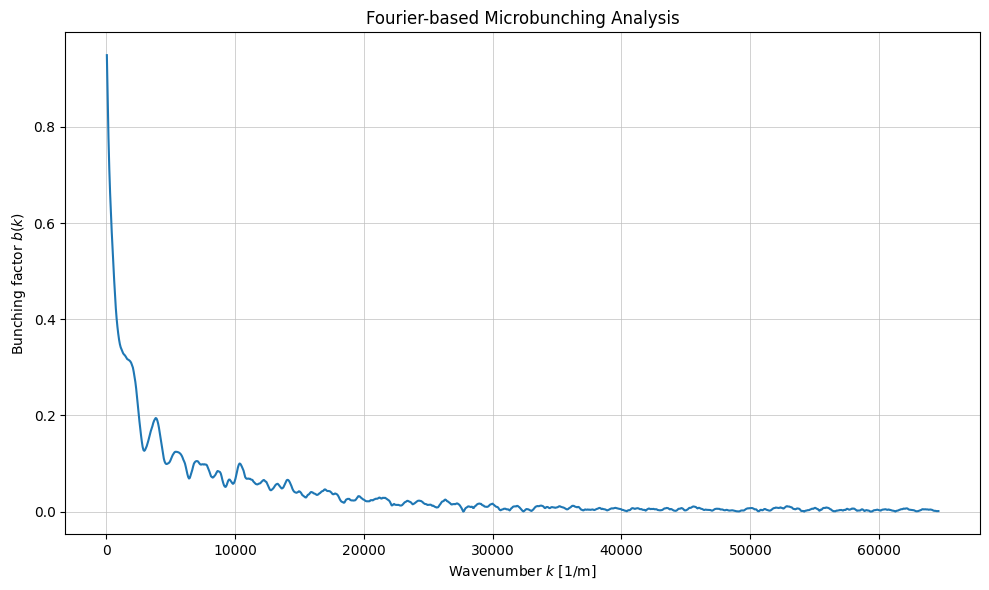

In [221]:
import numpy as np
import matplotlib.pyplot as plt

# Extract z positions (longitudinal coordinates) in meters
z_meters = p_array_wake.rparticles[4]  # assuming this is AFTER tracking

# Histogram to get longitudinal density profile
nbins = 2048
zmin, zmax = z_meters.min(), z_meters.max()
hist, bin_edges = np.histogram(z_meters, bins=nbins, range=(zmin, zmax))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Perform FFT
fft_result = np.fft.fft(hist - np.mean(hist))  # remove DC offset
fft_freq = np.fft.fftfreq(nbins, d=(bin_centers[1] - bin_centers[0]))  # in 1/m

# Compute bunching factor magnitude
bunching = np.abs(fft_result) / np.sum(hist)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fft_freq[1:nbins//2], bunching[1:nbins//2])
plt.xlabel("Wavenumber $k$ [1/m]")
plt.ylabel("Bunching factor $b(k)$")
plt.title("Fourier-based Microbunching Analysis")
plt.grid(True)
plt.tight_layout()
plt.show()


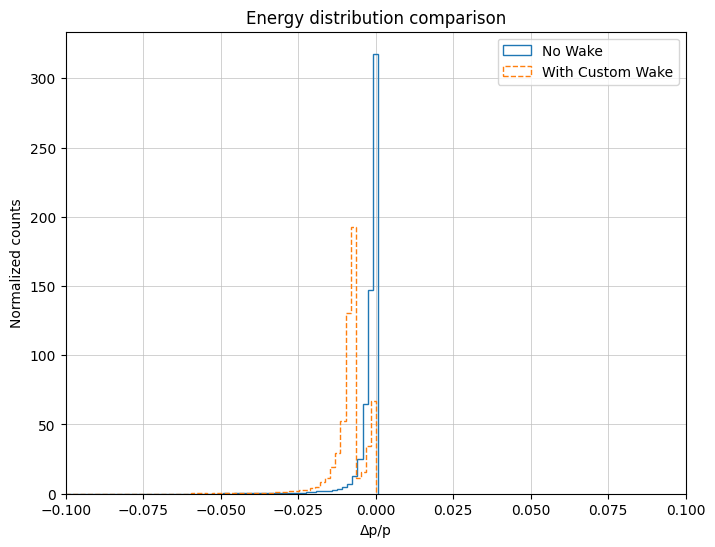

In [222]:
import matplotlib.pyplot as plt

# Energy distributions (Δp/p)
dp_p_no_wake = p_array_no_wake.rparticles[5]
dp_p_wake = p_array_wake.rparticles[5]

plt.figure(figsize=(8,6))
plt.hist(dp_p_no_wake, bins=200, histtype='step', label='No Wake', density=True)
plt.hist(dp_p_wake, bins=200, histtype='step', label='With Custom Wake', density=True, linestyle='--')
plt.xlabel('Δp/p')
plt.ylabel('Normalized counts')
plt.title('Energy distribution comparison')
plt.xlim(-0.1,0.1)
plt.grid(True)
plt.legend()
plt.show()


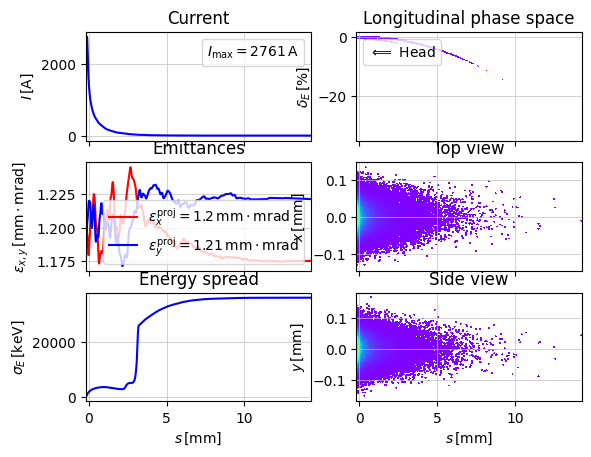

In [223]:
show_e_beam(p_array_no_wake)

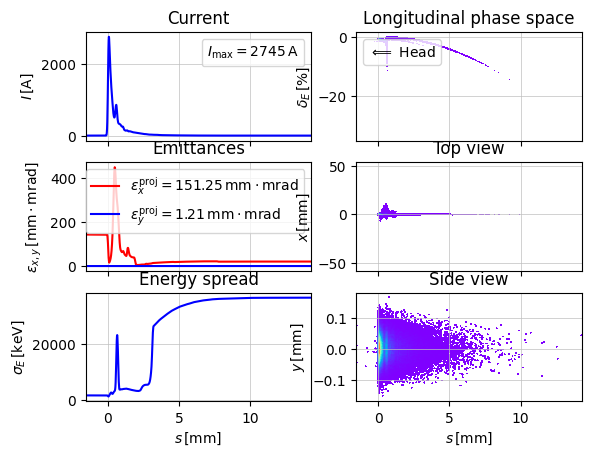

In [224]:
show_e_beam(p_array_wake)

In [225]:
import numpy as np

# particle data 
np.save("particles_rparticles_wake.npy", p_array_wake.rparticles)

# charge array
np.save("particles_q_array_wake.npy", p_array_wake.q_array)
